# KLASIFIKASI KUALITAS UDARA KOTA-KOTA BESAR DENGAN MODEL DECISION TREE
---

## Anggota Kelompok

| No 	| Nama 	| NIM 	|
|---	|--------------------------	|--------------------	|
| 1 	| Riyan Naffa Nusafara 	| 23/516897/TK/56833 	|
| 2 	| Fadel Aulia Naldi    	| Belum tau             |

## Overview

### Topic Overview

Topik yang kami angkat adalah pengukuran kualitas udara pada kota-kota besar dengan *feature* berupa polutan-polutan udara, antara lain $\text{PM}_{2.5}$, $\text{PM}_{10}$, $\text{O}_{3}$, $\text{NO}_{2}$, $\text{SO}_{2}$, dan $\text{CO}$ serta *target* berupa penilaian kualitas udara yang terdiri atas tiga kelas: *normal*, *elevated*, dan *spiked*. *Normal* merupakan keadaan udara dengan polutan di bawah tingkat bahaya, *elevated* merupakan keadaan udara dengan polutan berada pada tingkat bahaya, dan *spiked* merupakan keadaan udara dengan tingkat polutan yang sangat berbahaya.

### Dataset Overview

Setiap file CSV, yang merupakan data kualitas udara dari kota-kota di dunia, memiliki beberapa kolom:

| location_id | location_name | parameter | value | unit | datetimeUtc | datetimeLocal | timezone | latitude | longitude | country_iso | isMobile | isMonitor | owner_name | provider |

Kolom-kolom seperti `country_iso`, `isMobile`, `isMonitor`, `owner_name`, dan `provider` tidak dibutuhkan dalam analisis sehingga dapat dihilangkan.

Kolom `parameter` berisi polutan-polutan udara atau kondisi udara lainnya. Supaya model klasifikasi dapat berjalan dan dilatih, *dataset* perlu diubah menjadi *wide format*, yakni nilai dari satu parameter atau polutan mengisi satu kolom. Mengubah data menjadi *wide format* dilakukan pada bagian [pemrosesan data](#Data-Preprocessing).

Kolom `parameter` yang akan dianalisis antara lain `pm25`, `pm10`, `o3`, `no2`, `so2`, dan `co`. Nilai `parameter` lainnya dapat dihilangkan.

Import pandas untuk manipulasi data dan os untuk mengambil data dari *directory*.

In [ ]:
import pandas as pd
import os

In [11]:
# Tentukan path ke direktori data
data_dir = "../data/"

# List seluruh file .csv
files = os.listdir(data_dir)
print(f"Files in {data_dir}: {files}\n\n")

# Ambil nama kota dengan menghilangkan akhiran .csv
cities = [file[:-4] for file in files if file.endswith('.csv')]

Files in ../data/: ['Depok.csv', 'Hanoi.csv', 'London.csv', 'Madrid.csv', 'Napoli.csv', 'New Delhi.csv', 'New Jersey.csv', 'Paris.csv', 'Riverside.csv']




In [ ]:
# Loop untuk setiap kota dan baca file CSV
for city in cities:
    print(f"\n========== City: {city} ==========\n")
    # Baca file CSV
    # Gunakan try-except untuk menangani kesalahan saat membaca file
    try:
        # Baca file CSV dengan parameter datetimeUtc sebagai datetime
        df = pd.read_csv(os.path.join(data_dir, f"{city}.csv"), parse_dates=['datetimeUtc'])
        df['datetimeUtc'] = pd.to_datetime(df['datetimeUtc'])
        
        # Tampilkan parameter berbeda pada setiap kota
        print(f"{city} parameter counts:\n", df['parameter'].value_counts(), "\n")
        print("Unique parameter: ", df['parameter'].unique())

        # Tampilkan deskripsi data dan statistik dasar
        print(f"Shape of the dataset: {df.shape}")
        print("Columns in the dataset:", df.columns)
        print("Data types:\n", df.dtypes)
        print("Missing values:\n", df.isnull().sum())
        print("Basic statistics:\n", df.describe())
        
        # Tampilkan 5 baris acak dari dataset
        print("5 random rows:\n", df.sample(5))
        
    except Exception as e:
        # Jika terjadi kesalahan, tampilkan pesan kesalahan
        print(f"Error processing {city}: {e}")


========== City: Depok ==========

Depok parameter counts:
 parameter
pm1                 1000
pm10                1000
pm25                1000
relativehumidity    1000
temperature         1000
um003               1000
Name: count, dtype: int64 

Unique parameter:  ['pm1' 'pm10' 'pm25' 'relativehumidity' 'temperature' 'um003']
Shape of the dataset: (6000, 15)
Columns in the dataset: Index(['location_id', 'location_name', 'parameter', 'value', 'unit',
       'datetimeUtc', 'datetimeLocal', 'timezone', 'latitude', 'longitude',
       'country_iso', 'isMobile', 'isMonitor', 'owner_name', 'provider'],
      dtype='object')
Data types:
 location_id                    int64
location_name                 object
parameter                     object
value                        float64
unit                          object
datetimeUtc      datetime64[ns, UTC]
datetimeLocal                 object
timezone                      object
latitude                     float64
longitude                

## Data Preprocessing

In [12]:
# Path ke direktori data
data_dir = "../data/"

# List seluruh file .csv
files = os.listdir(data_dir)
print(f"Files in {data_dir}: {files}\n\n")

# Ambil nama kota dengan menghilangkan akhiran .csv
cities = [file[:-4] for file in files if file.endswith('.csv')]

# Daftar kolom yang akan dihapus
columns_to_drop = ['provider', 'owner_name', 'isMonitor', 'isMobile', 'country_iso']

for city in cities:
    print(f"========== City: {city} ==========\n")
    try:
        df = pd.read_csv(os.path.join(data_dir, f"{city}.csv"), parse_dates=['datetimeUtc'])
        df.drop(columns=columns_to_drop, inplace=True, errors='ignore')
        df['datetimeUtc'] = pd.to_datetime(df['datetimeUtc'])
        
        # Pivot tabel untuk memecah nilai unik parameter menjadi kolom-kolom yang berbeda
        # dengan index berupa datetime 
        df_wide = df.pivot_table(index=['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude'],
                                 columns='parameter', 
                                 values='value').reset_index()

        print(f"Shape of the dataset: {df_wide.shape}")
        print("Columns in the dataset:", df_wide.columns)
        print("Data types:\n", df_wide.dtypes)
        print("Missing values:\n", df_wide.isnull().sum())
        print("Basic statistics:\n", df_wide.describe())
        
        # Tampilkan 5 baris acak dari dataset
        print("5 random rows:\n", df.sample(5))
        
        # Set datetime sebagai index
        df_wide['datetimeUtc'] = pd.to_datetime(df_wide['datetimeUtc'])
        df_wide.set_index('datetimeUtc', inplace=False)
        
        # Simpan dataframe ke file CSV pada direktori ../data_processed/
        data_processed_dir = "../data_processed/"
        os.makedirs(data_processed_dir, exist_ok=True)
        df_wide.to_csv(os.path.join(data_processed_dir, f"{city}_processed.csv"), index=False)

    except Exception as e:
        print(f"Could not process file {city}.csv: {e}")

Files in ../data/: ['Depok.csv', 'Hanoi.csv', 'London.csv', 'Madrid.csv', 'Napoli.csv', 'New Delhi.csv', 'New Jersey.csv', 'Paris.csv', 'Riverside.csv']


========== City: Depok ==========

Shape of the dataset: (2309, 11)
Columns in the dataset: Index(['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude',
       'pm1', 'pm10', 'pm25', 'relativehumidity', 'temperature', 'um003'],
      dtype='object', name='parameter')
Data types:
 parameter
location_id                       int64
location_name                    object
datetimeUtc         datetime64[ns, UTC]
latitude                        float64
longitude                       float64
pm1                             float64
pm10                            float64
pm25                            float64
relativehumidity                float64
temperature                     float64
um003                           float64
dtype: object
Missing values:
 parameter
location_id            0
location_name          0
datet

## Visualisasi Data

Tampilkan *scatterplot* untuk setiap kota.

In [8]:
import matplotlib.pyplot as plt
import math

Files in ../data_processed/: ['Depok_processed.csv', 'Hanoi_processed.csv', 'London_processed.csv', 'Madrid_processed.csv', 'Napoli_processed.csv', 'New Delhi_processed.csv', 'New Jersey_processed.csv', 'Paris_processed.csv', 'Riverside_processed.csv']


========== City: Depok ==========

Shape of the dataset: (2309, 11)
Columns in the dataset: Index(['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude',
       'pm1', 'pm10', 'pm25', 'relativehumidity', 'temperature', 'um003'],
      dtype='object')
Data types:
 location_id                       int64
location_name                    object
datetimeUtc         datetime64[ns, UTC]
latitude                        float64
longitude                       float64
pm1                             float64
pm10                            float64
pm25                            float64
relativehumidity                float64
temperature                     float64
um003                           float64
dtype: object
Missing va

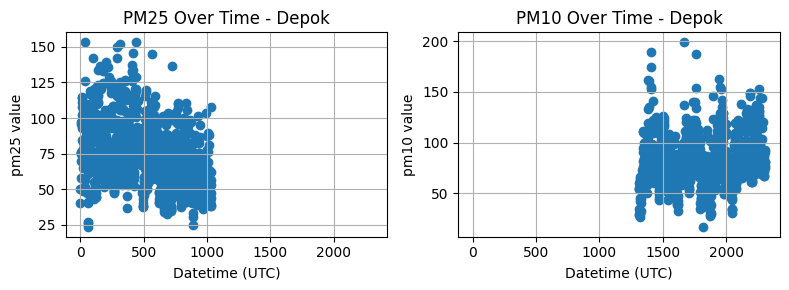

========== City: Hanoi ==========

Shape of the dataset: (1035, 11)
Columns in the dataset: Index(['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude',
       'co', 'no2', 'o3', 'pm10', 'pm25', 'so2'],
      dtype='object')
Data types:
 location_id                    int64
location_name                 object
datetimeUtc      datetime64[ns, UTC]
latitude                     float64
longitude                    float64
co                           float64
no2                          float64
o3                           float64
pm10                         float64
pm25                         float64
so2                          float64
dtype: object
Missing values:
 location_id       0
location_name     0
datetimeUtc       0
latitude          0
longitude         0
co               35
no2              35
o3               35
pm10             35
pm25             35
so2              35
dtype: int64
Basic statistics:
        location_id      latitude  longitude           

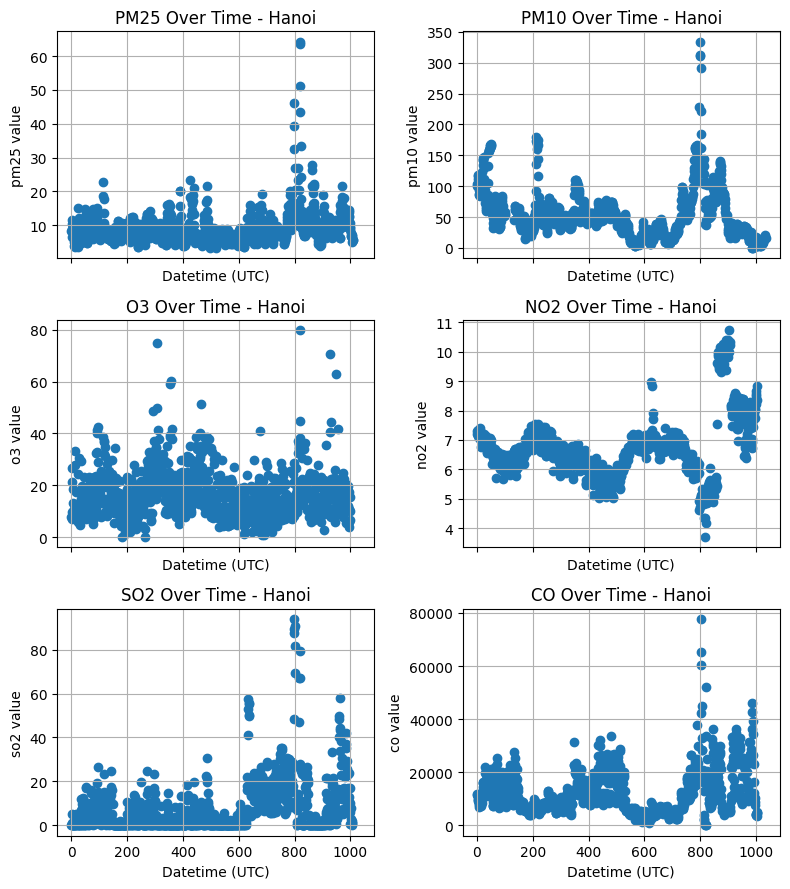

========== City: London ==========

Shape of the dataset: (2067, 11)
Columns in the dataset: Index(['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude',
       'co', 'no2', 'o3', 'pm10', 'pm25', 'so2'],
      dtype='object')
Data types:
 location_id                    int64
location_name                 object
datetimeUtc      datetime64[ns, UTC]
latitude                     float64
longitude                    float64
co                           float64
no2                          float64
o3                           float64
pm10                         float64
pm25                         float64
so2                          float64
dtype: object
Missing values:
 location_id         0
location_name       0
datetimeUtc         0
latitude            0
longitude           0
co               1067
no2              1067
o3               1067
pm10             1067
pm25             1067
so2              1067
dtype: int64
Basic statistics:
        location_id      latitud

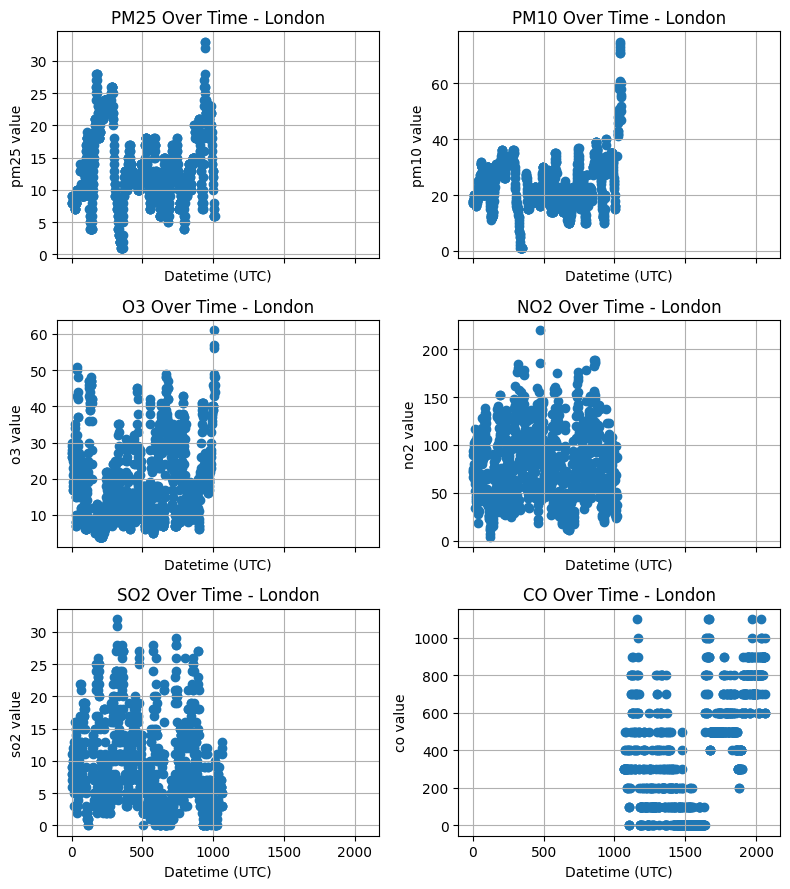

========== City: Madrid ==========

Shape of the dataset: (2174, 12)
Columns in the dataset: Index(['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude',
       'co', 'no', 'no2', 'o3', 'pm10', 'pm25', 'so2'],
      dtype='object')
Data types:
 location_id                    int64
location_name                 object
datetimeUtc      datetime64[ns, UTC]
latitude                     float64
longitude                    float64
co                           float64
no                           float64
no2                          float64
o3                           float64
pm10                         float64
pm25                         float64
so2                          float64
dtype: object
Missing values:
 location_id         0
location_name       0
datetimeUtc         0
latitude            0
longitude           0
co               1174
no               1174
no2              1174
o3               1174
pm10             1174
pm25             1174
so2              117

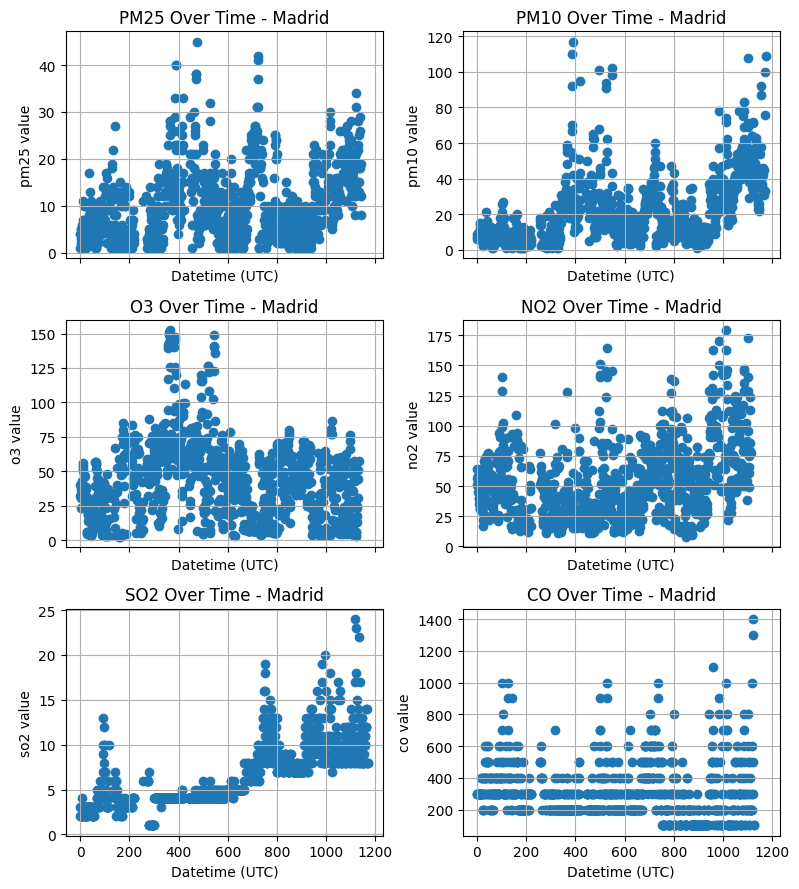

========== City: Napoli ==========

Shape of the dataset: (1148, 10)
Columns in the dataset: Index(['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude',
       'co', 'no2', 'pm10', 'pm25', 'so2'],
      dtype='object')
Data types:
 location_id                    int64
location_name                 object
datetimeUtc      datetime64[ns, UTC]
latitude                     float64
longitude                    float64
co                           float64
no2                          float64
pm10                         float64
pm25                         float64
so2                          float64
dtype: object
Missing values:
 location_id        0
location_name      0
datetimeUtc        0
latitude           0
longitude          0
co               148
no2              148
pm10             148
pm25             148
so2              148
dtype: int64
Basic statistics:
        location_id    latitude     longitude           co          no2  \
count       1148.0  1148.00000  

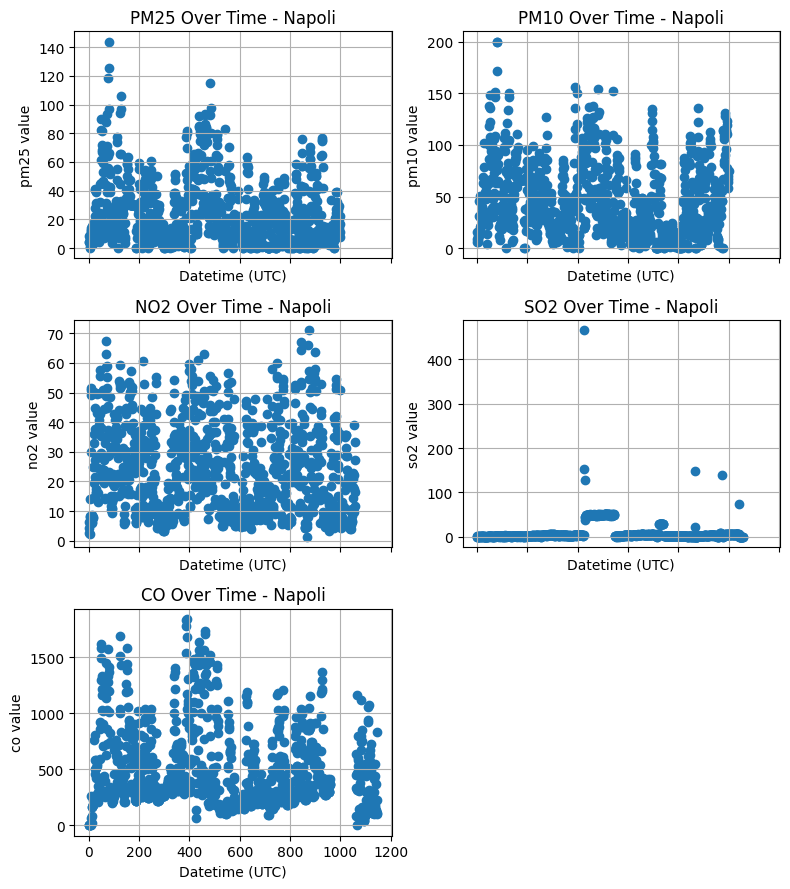

========== City: New Delhi ==========

Shape of the dataset: (2572, 14)
Columns in the dataset: Index(['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude',
       'co', 'no', 'no2', 'o3', 'pm10', 'pm25', 'relativehumidity', 'so2',
       'temperature'],
      dtype='object')
Data types:
 location_id                       int64
location_name                    object
datetimeUtc         datetime64[ns, UTC]
latitude                        float64
longitude                       float64
co                              float64
no                              float64
no2                             float64
o3                              float64
pm10                            float64
pm25                            float64
relativehumidity                float64
so2                             float64
temperature                     float64
dtype: object
Missing values:
 location_id            0
location_name          0
datetimeUtc            0
latitude               0
l

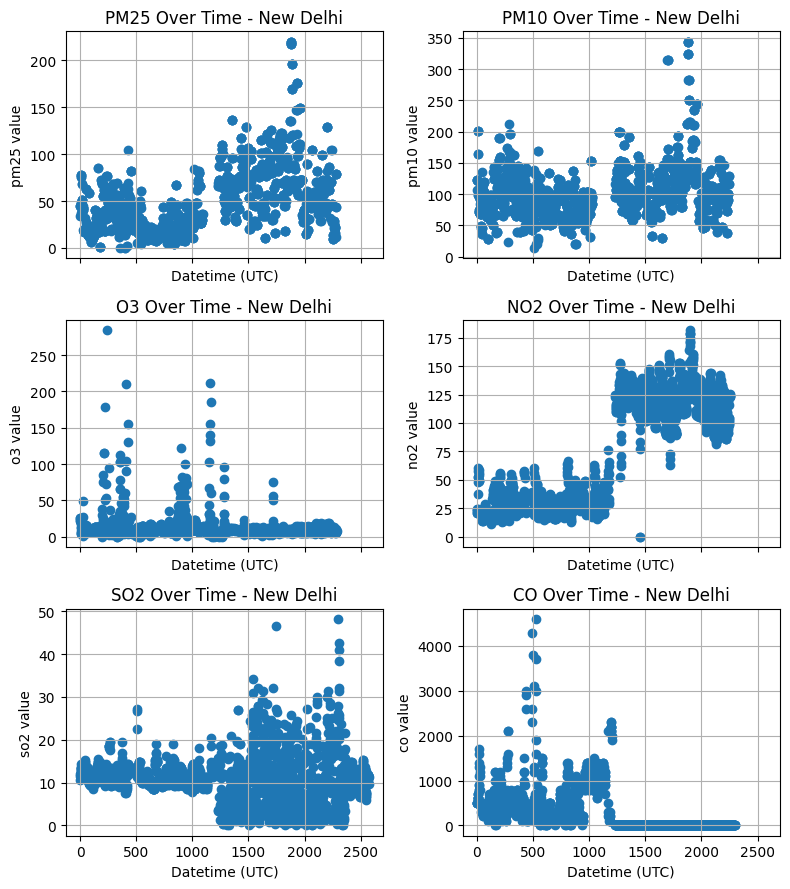

========== City: New Jersey ==========

Shape of the dataset: (3085, 11)
Columns in the dataset: Index(['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude',
       'no', 'no2', 'nox', 'o3', 'pm25', 'so2'],
      dtype='object')
Data types:
 location_id                    int64
location_name                 object
datetimeUtc      datetime64[ns, UTC]
latitude                     float64
longitude                    float64
no                           float64
no2                          float64
nox                          float64
o3                           float64
pm25                         float64
so2                          float64
dtype: object
Missing values:
 location_id         0
location_name       0
datetimeUtc         0
latitude            0
longitude           0
no               2085
no2              2085
nox              2085
o3               2085
pm25             2085
so2              2085
dtype: int64
Basic statistics:
        location_id      lati

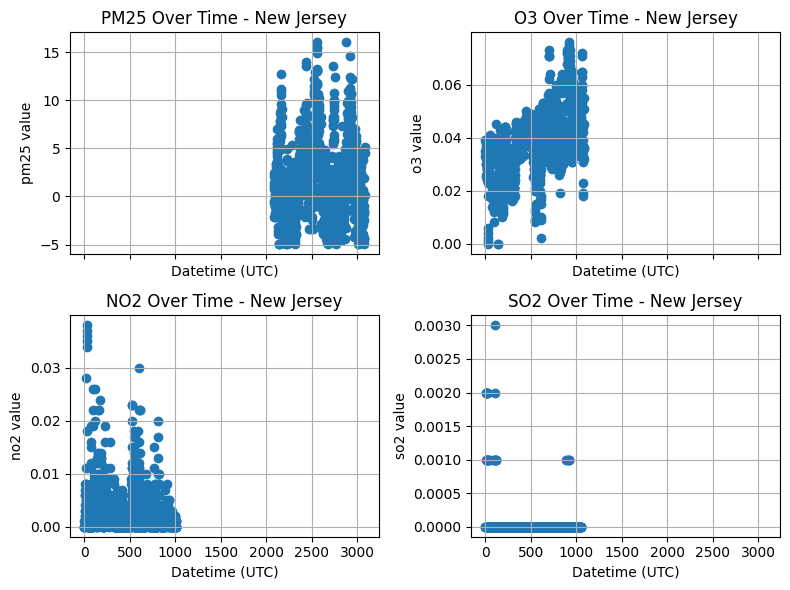

========== City: Paris ==========

Shape of the dataset: (2121, 11)
Columns in the dataset: Index(['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude',
       'no', 'no2', 'o3', 'pm10', 'pm25', 'so2'],
      dtype='object')
Data types:
 location_id                    int64
location_name                 object
datetimeUtc      datetime64[ns, UTC]
latitude                     float64
longitude                    float64
no                           float64
no2                          float64
o3                           float64
pm10                         float64
pm25                         float64
so2                          float64
dtype: object
Missing values:
 location_id         0
location_name       0
datetimeUtc         0
latitude            0
longitude           0
no               1121
no2              1121
o3               1121
pm10             1121
pm25             1121
so2              1121
dtype: int64
Basic statistics:
        location_id      latitude

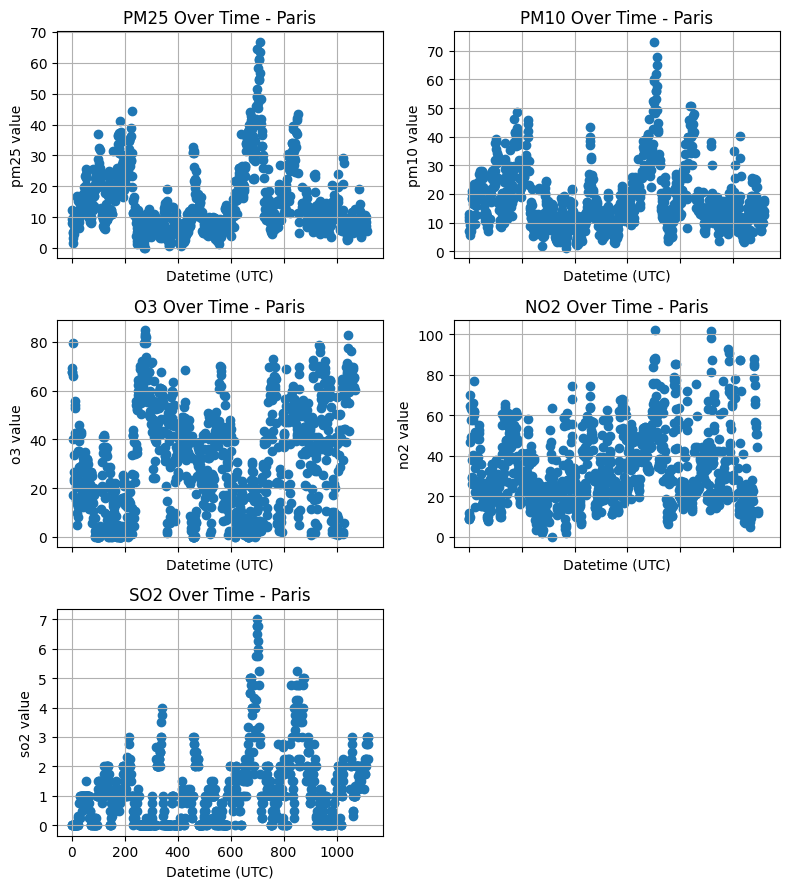

========== City: Riverside ==========

Shape of the dataset: (2125, 13)
Columns in the dataset: Index(['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude',
       'co', 'no', 'no2', 'nox', 'o3', 'pm10', 'pm25', 'so2'],
      dtype='object')
Data types:
 location_id                    int64
location_name                 object
datetimeUtc      datetime64[ns, UTC]
latitude                     float64
longitude                    float64
co                           float64
no                           float64
no2                          float64
nox                          float64
o3                           float64
pm10                         float64
pm25                         float64
so2                          float64
dtype: object
Missing values:
 location_id         0
location_name       0
datetimeUtc         0
latitude            0
longitude           0
co               1125
no               1125
no2              1125
nox              1125
o3               

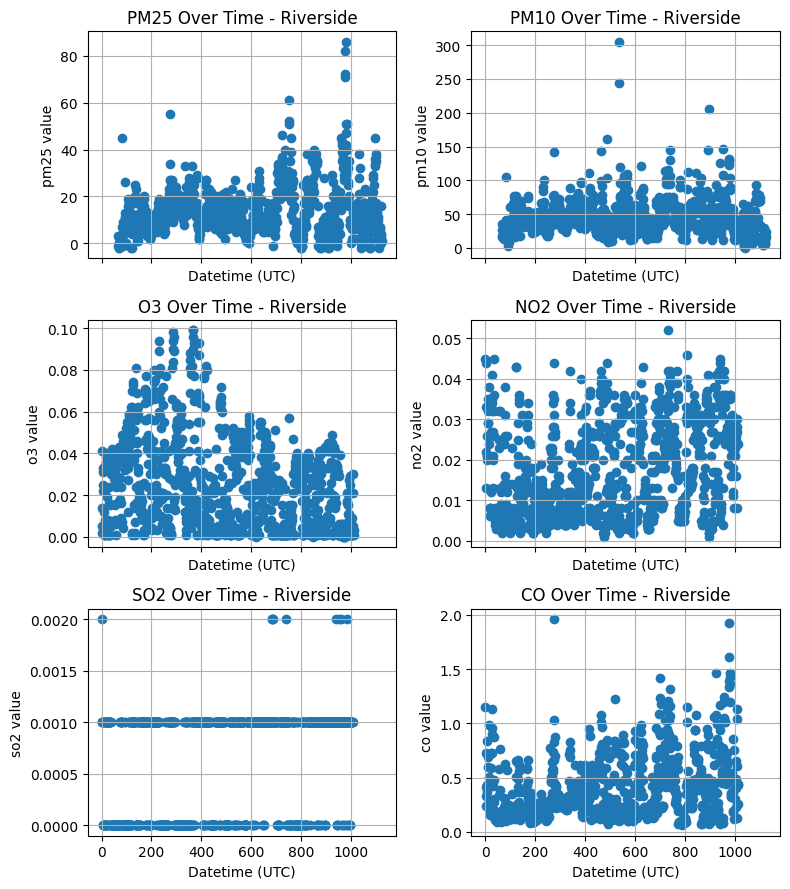

In [14]:
# Required for inline plotting in Jupyter
%matplotlib inline

# Define the path to the data directory
data_dir = "../data_processed/"

# List all files in the data directory
files = os.listdir(data_dir)
print(f"Files in {data_dir}: {files}\n\n")

cities = [file[:-14] for file in files if file.endswith('.csv')]

for city in cities:
    print(f"========== City: {city} ==========\n")
    try:
        df_wide = pd.read_csv(os.path.join(data_dir, f"{city}_processed.csv"), parse_dates=['datetimeUtc'])
        df_wide['datetimeUtc'] = pd.to_datetime(df_wide['datetimeUtc'])

        print(f"Shape of the dataset: {df_wide.shape}")
        print("Columns in the dataset:", df_wide.columns)
        print("Data types:\n", df_wide.dtypes)
        print("Missing values:\n", df_wide.isnull().sum())
        print("Basic statistics:\n", df_wide.describe())
        print("First 5 rows:\n", df_wide.head(), "\n")

        pollutant_cols = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']
        available_pollutants = [col for col in pollutant_cols if col in df_wide.columns]

        # Plotting in collage form
        all_cols = available_pollutants
        n = len(all_cols)
        if n == 0:
            print(f"No pollutant data available for {city}")
            continue

        cols = 2
        rows = math.ceil(n / cols)

        fig, axes = plt.subplots(rows, cols, figsize=(8, 3 * rows), sharex=True)
        axes = axes.flatten()

        for i, col in enumerate(all_cols):
            axes[i].scatter(df_wide.index, df_wide[col], color='tab:blue')
            axes[i].set_title(f"{col.upper()} Over Time - {city}")
            axes[i].set_xlabel("Datetime (UTC)")
            axes[i].set_ylabel(f"{col} value")
            axes[i].grid(True)

        # Hide unused subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        fig.tight_layout()
        plt.show()  # <== Show plot inline

    except Exception as e:
        print(f"Could not process file {city}.csv: {e}")

## Pengembangan Model

## Model Training dan Validasi

## Model Testing

## Kesimpulan